<a href="https://colab.research.google.com/github/hazim-albaak/SmartBelt/blob/main/SmartBelt_DT_Only.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SmartBelt — Decision Tree Results & Figures
Generates all figures with Decision Tree as the selected model.

In [ ]:
# ================================================================
# CELL 1 — Install Libraries
# ================================================================
!pip install scikit-learn pandas numpy matplotlib joblib -q
print('Libraries ready')

Libraries ready


Upload your dataset CSV:


Saving features_new_thresholds.csv to features_new_thresholds.csv
Dataset loaded: 26 subjects | RISK=16 SAFE=10
Running LOO-CV...
  Random Forest          Acc: 84.6% F1:0.867 errors:[np.int64(7), np.int64(20), np.int64(23), np.int64(24)]
  Gradient Boosting      Acc: 92.3% F1:0.938 errors:[np.int64(7), np.int64(23)]
  Extra Trees            Acc: 92.3% F1:0.938 errors:[np.int64(7), np.int64(23)]
  AdaBoost               Acc: 88.5% F1:0.909 errors:[np.int64(7), np.int64(18), np.int64(23)]
  Bagging                Acc: 92.3% F1:0.938 errors:[np.int64(7), np.int64(23)]
  Logistic Regression    Acc: 92.3% F1:0.938 errors:[np.int64(7), np.int64(23)]
  Ridge Classifier       Acc: 92.3% F1:0.938 errors:[np.int64(7), np.int64(23)]
  SVM (RBF)              Acc: 92.3% F1:0.938 errors:[np.int64(7), np.int64(23)]
  SVM (Linear)           Acc: 92.3% F1:0.938 errors:[np.int64(7), np.int64(23)]
  SVM (Poly)             Acc: 92.3% F1:0.941 errors:[np.int64(7), np.int64(21)]
  KNN (k=3)              Acc

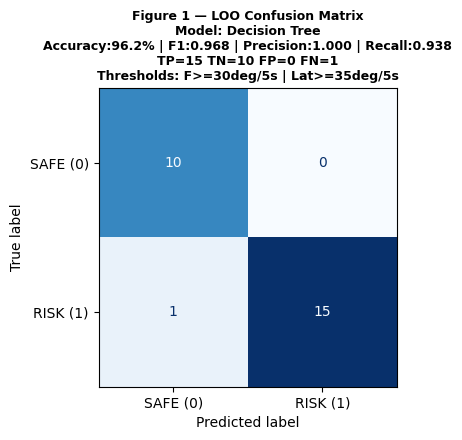

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

fig1 saved


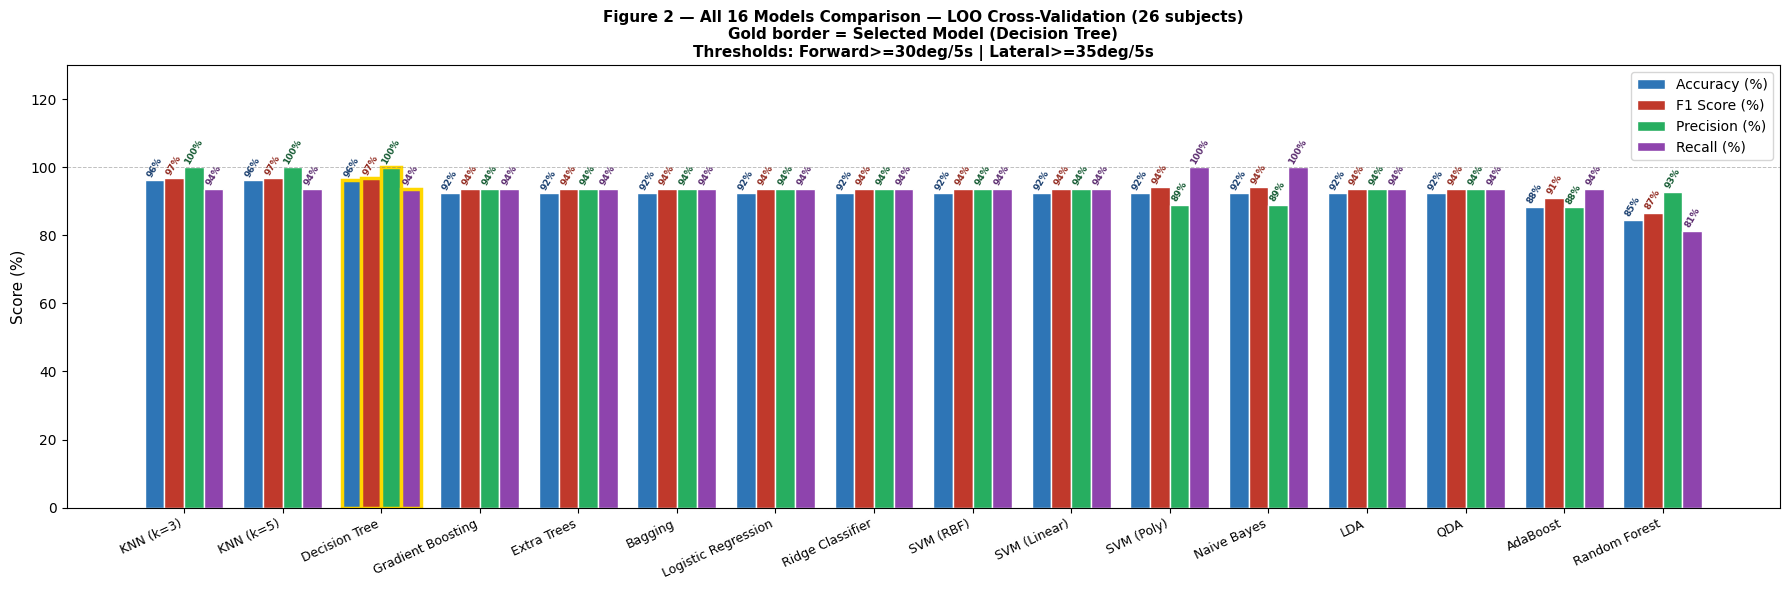

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

fig2 saved


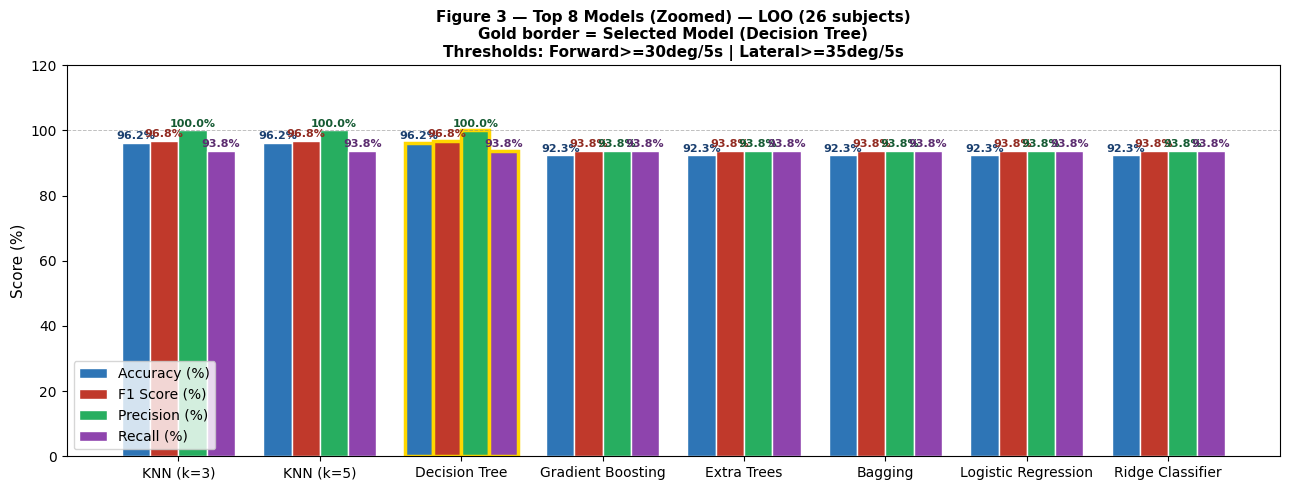

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

fig3 saved


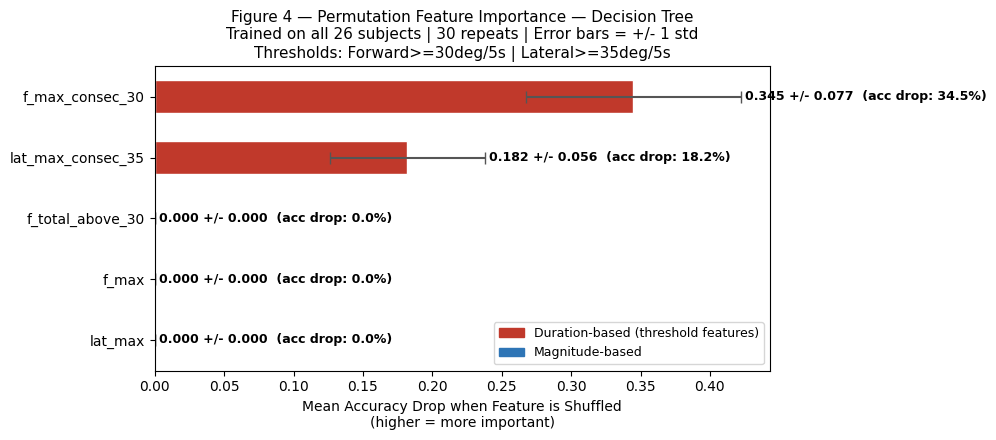

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

fig4 saved


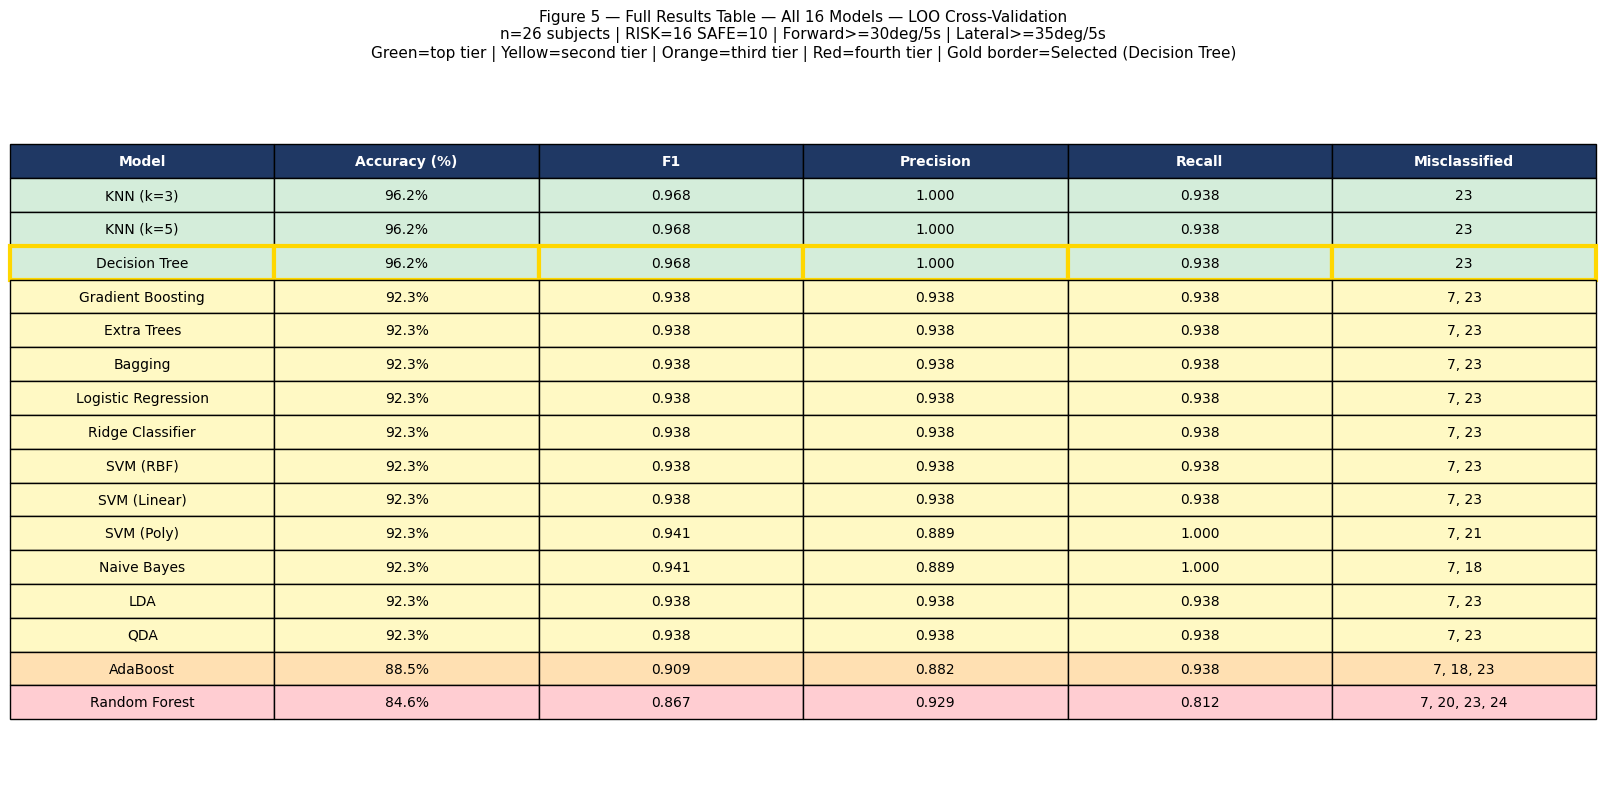

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

fig5 saved

All 5 figures downloaded successfully
Selected model: Decision Tree
Accuracy: 96.2% | F1: 0.968 | Precision: 1.000 | Recall: 0.938


In [ ]:
# ================================================================
# CELL 2 — Upload Dataset, Train 16 Models, All Figures for DT
# ================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble            import (RandomForestClassifier,
                                          GradientBoostingClassifier,
                                          ExtraTreesClassifier,
                                          AdaBoostClassifier,
                                          BaggingClassifier)
from sklearn.linear_model        import LogisticRegression, RidgeClassifier
from sklearn.svm                 import SVC
from sklearn.neighbors           import KNeighborsClassifier
from sklearn.tree                import DecisionTreeClassifier
from sklearn.naive_bayes         import GaussianNB
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis,
                                             QuadraticDiscriminantAnalysis)
from sklearn.model_selection     import LeaveOneOut
from sklearn.preprocessing       import StandardScaler
from sklearn.metrics             import (accuracy_score, f1_score,
                                          confusion_matrix, ConfusionMatrixDisplay,
                                          precision_score, recall_score)
from google.colab                import files

# Thresholds
THR_F   = 30
THR_LAT = 35
THR_DUR = 5

FEATURES = [
    'f_max_consec_30',
    'lat_max_consec_35',
    'f_max',
    'lat_max',
    'f_total_above_30',
]

MODELS = {
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_leaf=2, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, max_depth=2, learning_rate=0.1, random_state=42),
    'Extra Trees':         ExtraTreesClassifier(n_estimators=200, max_depth=3, min_samples_leaf=2, random_state=42),
    'AdaBoost':            AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42),
    'Bagging':             BaggingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Ridge Classifier':    RidgeClassifier(alpha=1.0),
    'SVM (RBF)':           SVC(kernel='rbf',    C=1.0, probability=True, random_state=42),
    'SVM (Linear)':        SVC(kernel='linear', C=1.0, probability=True, random_state=42),
    'SVM (Poly)':          SVC(kernel='poly',   C=1.0, probability=True, random_state=42),
    'KNN (k=3)':           KNeighborsClassifier(n_neighbors=3),
    'KNN (k=5)':           KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':       DecisionTreeClassifier(max_depth=3, random_state=42),
    'Naive Bayes':         GaussianNB(),
    'LDA':                 LinearDiscriminantAnalysis(),
    'QDA':                 QuadraticDiscriminantAnalysis(reg_param=0.5),
}

# Upload dataset
print('Upload your dataset CSV:')
uploaded = files.upload()
fname    = list(uploaded.keys())[0]
df       = pd.read_csv(fname) if fname.endswith('.csv') else pd.read_excel(fname)
df.columns = [c.strip().split(' ')[0].split('(')[0].strip() for c in df.columns]

X  = df[FEATURES].values.astype(float)
y  = df['label'].values.astype(int)
N  = len(df)
print(f'Dataset loaded: {N} subjects | RISK={int((y==1).sum())} SAFE={int((y==0).sum())}')

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# LOO-CV all 16 models
print('Running LOO-CV...')
loo        = LeaveOneOut()
cv_results = {}

for name, model in MODELS.items():
    y_true_all, y_pred_all = [], []
    for train_idx, test_idx in loo.split(X_scaled):
        m = model.__class__(**model.get_params())
        try:
            m.fit(X_scaled[train_idx], y[train_idx])
            pred = int(m.predict(X_scaled[test_idx])[0])
        except Exception:
            pred = int(np.bincount(y[train_idx]).argmax())
        y_true_all.append(int(y[test_idx][0]))
        y_pred_all.append(pred)
    yt = np.array(y_true_all)
    yp = np.array(y_pred_all)
    cv_results[name] = {
        'accuracy':  accuracy_score(yt, yp),
        'f1':        f1_score(yt, yp, zero_division=0),
        'precision': precision_score(yt, yp, zero_division=0),
        'recall':    recall_score(yt, yp, zero_division=0),
        'y_true': yt, 'y_pred': yp
    }
    wrong = list(np.where(yt != yp)[0] + 1)
    print(f'  {name:22s} Acc:{cv_results[name]["accuracy"]*100:5.1f}% F1:{cv_results[name]["f1"]:.3f} errors:{wrong}')

# ── FORCE Decision Tree as selected model ────────────────────
best_name = 'Decision Tree'
best      = cv_results[best_name]
names_s   = sorted(cv_results, key=lambda k: cv_results[k]['accuracy'], reverse=True)

print(f'\nSelected model: {best_name}')
print(f'  Accuracy  : {best["accuracy"]*100:.1f}%')
print(f'  F1        : {best["f1"]:.3f}')
print(f'  Precision : {best["precision"]:.3f}')
print(f'  Recall    : {best["recall"]:.3f}')

# Train final DT on all data
final_model = DecisionTreeClassifier(max_depth=3, random_state=42)
final_model.fit(X_scaled, y)

# ================================================================
# FIGURE 1 — Confusion Matrix (Decision Tree)
# ================================================================
fig1, ax1 = plt.subplots(figsize=(5.5, 4.5))
cm = confusion_matrix(best['y_true'], best['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['SAFE (0)', 'RISK (1)']).plot(
    ax=ax1, colorbar=False, cmap='Blues')
tn, fp, fn, tp = cm.ravel()
ax1.set_title(
    f'Figure 1 — LOO Confusion Matrix\n'
    f'Model: {best_name}\n'
    f'Accuracy:{best["accuracy"]*100:.1f}% | F1:{best["f1"]:.3f} | Precision:{best["precision"]:.3f} | Recall:{best["recall"]:.3f}\n'
    f'TP={tp} TN={tn} FP={fp} FN={fn}\n'
    f'Thresholds: F>={THR_F}deg/{THR_DUR}s | Lat>={THR_LAT}deg/{THR_DUR}s',
    fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_confusion_matrix_DT.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('fig1_confusion_matrix_DT.png')
print('fig1 saved')

# ================================================================
# FIGURE 2 — All 16 Models Bar Chart
# ================================================================
accs_s = [cv_results[n]['accuracy']*100  for n in names_s]
f1s_s  = [cv_results[n]['f1']*100        for n in names_s]
pres_s = [cv_results[n]['precision']*100 for n in names_s]
recs_s = [cv_results[n]['recall']*100    for n in names_s]
x2 = np.arange(len(names_s))
w2 = 0.20

fig2, ax2 = plt.subplots(figsize=(18, 6))
b_acc = ax2.bar(x2-1.5*w2, accs_s, w2, label='Accuracy (%)',  color='#2E75B6', edgecolor='white')
b_f1  = ax2.bar(x2-0.5*w2, f1s_s,  w2, label='F1 Score (%)',  color='#C0392B', edgecolor='white')
b_pre = ax2.bar(x2+0.5*w2, pres_s, w2, label='Precision (%)', color='#27AE60', edgecolor='white')
b_rec = ax2.bar(x2+1.5*w2, recs_s, w2, label='Recall (%)',    color='#8E44AD', edgecolor='white')

bi2 = names_s.index(best_name)
for b in [b_acc[bi2], b_f1[bi2], b_pre[bi2], b_rec[bi2]]:
    b.set_edgecolor('gold'); b.set_linewidth(2.5)

for bars, vals, col in [(b_acc,accs_s,'#1A3F6F'),(b_f1,f1s_s,'#922B21'),
                         (b_pre,pres_s,'#145A32'),(b_rec,recs_s,'#5B2C6F')]:
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.0f}%', ha='center', va='bottom',
                 fontsize=6.5, fontweight='bold', color=col, rotation=60)

ax2.set_xticks(x2)
ax2.set_xticklabels(names_s, fontsize=9, rotation=25, ha='right')
ax2.set_ylim([0, 130])
ax2.set_ylabel('Score (%)', fontsize=11)
ax2.set_title(
    f'Figure 2 — All {len(MODELS)} Models Comparison — LOO Cross-Validation ({N} subjects)\n'
    f'Gold border = Selected Model ({best_name})\n'
    f'Thresholds: Forward>={THR_F}deg/{THR_DUR}s | Lateral>={THR_LAT}deg/{THR_DUR}s',
    fontsize=11, fontweight='bold')
ax2.legend(fontsize=10, loc='upper right')
ax2.axhline(100, color='grey', linestyle='--', linewidth=0.7, alpha=0.5)
plt.tight_layout()
plt.savefig('fig2_all_models_DT.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('fig2_all_models_DT.png')
print('fig2 saved')

# ================================================================
# FIGURE 3 — Top 8 Models Zoomed
# ================================================================
top8 = names_s[:8]
x3   = np.arange(len(top8))
w3   = 0.20

fig3, ax3 = plt.subplots(figsize=(13, 5))
b3_acc = ax3.bar(x3-1.5*w3,[cv_results[n]['accuracy']*100  for n in top8],w3,label='Accuracy (%)',  color='#2E75B6',edgecolor='white')
b3_f1  = ax3.bar(x3-0.5*w3,[cv_results[n]['f1']*100        for n in top8],w3,label='F1 Score (%)',  color='#C0392B',edgecolor='white')
b3_pre = ax3.bar(x3+0.5*w3,[cv_results[n]['precision']*100 for n in top8],w3,label='Precision (%)', color='#27AE60',edgecolor='white')
b3_rec = ax3.bar(x3+1.5*w3,[cv_results[n]['recall']*100    for n in top8],w3,label='Recall (%)',    color='#8E44AD',edgecolor='white')

if best_name in top8:
    bi3 = top8.index(best_name)
    for b in [b3_acc[bi3], b3_f1[bi3], b3_pre[bi3], b3_rec[bi3]]:
        b.set_edgecolor('gold'); b.set_linewidth(2.5)

for bars, key, col in [('acc','accuracy','#1A3F6F'),('f1','f1','#922B21'),
                        ('pre','precision','#145A32'),('rec','recall','#5B2C6F')]:
    for bar, n in zip(eval(f'b3_{bars}'), top8):
        val = cv_results[n][key]*100
        ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=8, fontweight='bold', color=col)

ax3.set_xticks(x3)
ax3.set_xticklabels(top8, fontsize=10)
ax3.set_ylim([0, 120])
ax3.set_ylabel('Score (%)', fontsize=11)
ax3.set_title(
    f'Figure 3 — Top 8 Models (Zoomed) — LOO ({N} subjects)\n'
    f'Gold border = Selected Model ({best_name})\n'
    f'Thresholds: Forward>={THR_F}deg/{THR_DUR}s | Lateral>={THR_LAT}deg/{THR_DUR}s',
    fontsize=11, fontweight='bold')
ax3.legend(fontsize=10)
ax3.axhline(100, color='grey', linestyle='--', linewidth=0.7, alpha=0.5)
plt.tight_layout()
plt.savefig('fig3_top8_DT.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('fig3_top8_DT.png')
print('fig3 saved')

# ================================================================
# FIGURE 4 — Permutation Importance (Decision Tree)
# ================================================================
from sklearn.inspection import permutation_importance

perm  = permutation_importance(final_model, X_scaled, y, n_repeats=30, random_state=42, scoring='accuracy')
means = perm.importances_mean
stds  = perm.importances_std
order = np.argsort(means)
f_ord = [FEATURES[i] for i in order]
m_ord = means[order]
s_ord = stds[order]
c_ord = ['#C0392B' if 'consec' in f else '#2E75B6' for f in f_ord]

fig4, ax4 = plt.subplots(figsize=(10, 4.5))
bars4 = ax4.barh(f_ord, m_ord, xerr=s_ord, color=c_ord, edgecolor='white',
                  height=0.55, capsize=4, error_kw={'elinewidth':1.5,'ecolor':'#555'})

for bar, mean, std in zip(bars4, m_ord, s_ord):
    ax4.text(mean+std+0.003, bar.get_y()+bar.get_height()/2,
             f'{mean:.3f} +/- {std:.3f}  (acc drop: {mean*100:.1f}%)',
             va='center', fontsize=9, fontweight='bold')

red_p  = mpatches.Patch(color='#C0392B', label='Duration-based (threshold features)')
blue_p = mpatches.Patch(color='#2E75B6', label='Magnitude-based')
ax4.legend(handles=[red_p, blue_p], fontsize=9)
ax4.set_xlabel('Mean Accuracy Drop when Feature is Shuffled\n(higher = more important)', fontsize=10)
ax4.set_title(
    f'Figure 4 — Permutation Feature Importance — {best_name}\n'
    f'Trained on all {N} subjects | 30 repeats | Error bars = +/- 1 std\n'
    f'Thresholds: Forward>={THR_F}deg/{THR_DUR}s | Lateral>={THR_LAT}deg/{THR_DUR}s',
    fontsize=11)
plt.tight_layout()
plt.savefig('fig4_permutation_importance_DT.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('fig4_permutation_importance_DT.png')
print('fig4 saved')

# ================================================================
# FIGURE 5 — Full Results Table
# ================================================================
fig5, ax5 = plt.subplots(figsize=(16, 8))
ax5.axis('off')
col_labels = ['Model','Accuracy (%)','F1','Precision','Recall','Misclassified']
table_data = []
for name in names_s:
    r     = cv_results[name]
    wrong = [i+1 for i,(yt,yp) in enumerate(zip(r['y_true'],r['y_pred'])) if yt != yp]
    table_data.append([name, f"{r['accuracy']*100:.1f}%",
                       f"{r['f1']:.3f}", f"{r['precision']:.3f}",
                       f"{r['recall']:.3f}", ', '.join(map(str,wrong)) if wrong else '—'])

table = ax5.table(cellText=table_data, colLabels=col_labels,
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

for j in range(len(col_labels)):
    table[0,j].set_facecolor('#1F3864')
    table[0,j].set_text_props(color='white', fontweight='bold')

for i, name in enumerate(names_s):
    color = '#D4EDDA' if cv_results[name]['accuracy'] >= 0.96 else (
            '#FFF9C4' if cv_results[name]['accuracy'] >= 0.92 else (
            '#FFE0B2' if cv_results[name]['accuracy'] >= 0.88 else '#FFCDD2'))
    for j in range(len(col_labels)):
        table[i+1,j].set_facecolor(color)

# Gold border for Decision Tree
bi5 = names_s.index(best_name)
for j in range(len(col_labels)):
    table[bi5+1,j].set_edgecolor('#FFD700')
    table[bi5+1,j].set_linewidth(3)

ax5.set_title(
    f'Figure 5 — Full Results Table — All 16 Models — LOO Cross-Validation\n'
    f'n={N} subjects | RISK=16 SAFE=10 | '
    f'Forward>={THR_F}deg/{THR_DUR}s | Lateral>={THR_LAT}deg/{THR_DUR}s\n'
    f'Green=top tier | Yellow=second tier | Orange=third tier | Red=fourth tier | Gold border=Selected ({best_name})',
    fontsize=11, pad=20)
plt.tight_layout()
plt.savefig('fig5_results_table_DT.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('fig5_results_table_DT.png')
print('fig5 saved')

print('\nAll 5 figures downloaded successfully')
print(f'Selected model: {best_name}')
print(f'Accuracy: {best["accuracy"]*100:.1f}% | F1: {best["f1"]:.3f} | Precision: {best["precision"]:.3f} | Recall: {best["recall"]:.3f}')